# 📊 Sales Forecasting System  
## Business Intelligence & Predictive Analytics Framework  

**Author:** Harsha Vardhan Maradana

**Project:** FUTURE_ML_01  

---

## 🎯 Project Objective

This project builds a complete sales forecasting pipeline using historical business transaction data.  

The system performs:

- Data preprocessing & validation
- Exploratory Business Intelligence analysis
- Multi-dimensional sales aggregation
- Time-series forecasting using Prophet
- Model comparison with regression baseline
- KPI & Executive Summary generation
- Strategic business recommendations

---

## 🏢 Business Context

Accurate sales forecasting enables:

- Inventory optimization  
- Revenue planning  
- Seasonal demand management  
- Regional performance evaluation  
- Strategic marketing decisions  

This notebook provides a complete analytical workflow.

In [1]:
# 1️⃣ Import Libraries & Environment Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
import plotly.graph_objects as go
import plotly.express as px
import warnings
import calendar

warnings.filterwarnings("ignore")

plt.style.use("seaborn-v0_8")
sns.set_palette("Set2")

print("Environment initialized successfully.")

Environment initialized successfully.


# 📂 Step 1: Data Acquisition & Initial Inspection

We begin by loading the dataset and performing structural inspection.

Key checks:
- Data types
- Missing values
- Time range
- Transaction distribution

In [2]:
# 2️⃣ Load Dataset

df = pd.read_csv("sales_data.csv")
df.columns = df.columns.str.strip()

print("Dataset Shape:", df.shape)
print("\nColumn Information:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

df.head()

Dataset Shape: (9800, 18)

Column Information:
Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code      float64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
dtype: object

Missing Values:
Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


# 🧹 Step 2: Data Cleaning & Feature Engineering

We transform the dataset into a time-series ready format:

- Convert Order Date
- Extract Year, Month, Quarter
- Create Day Name
- Create rolling statistics

In [3]:
# 3️⃣ Data Cleaning & Feature Engineering
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df = df.sort_values('Order Date')

df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Quarter'] = df['Order Date'].dt.quarter
df['Day_Name'] = df['Order Date'].dt.day_name()

print("Feature engineering completed.")

Feature engineering completed.


# 📊 Step 3: Business Intelligence Analysis

We analyze:

- Total revenue trend
- Category contribution
- Regional performance
- Monthly growth trends

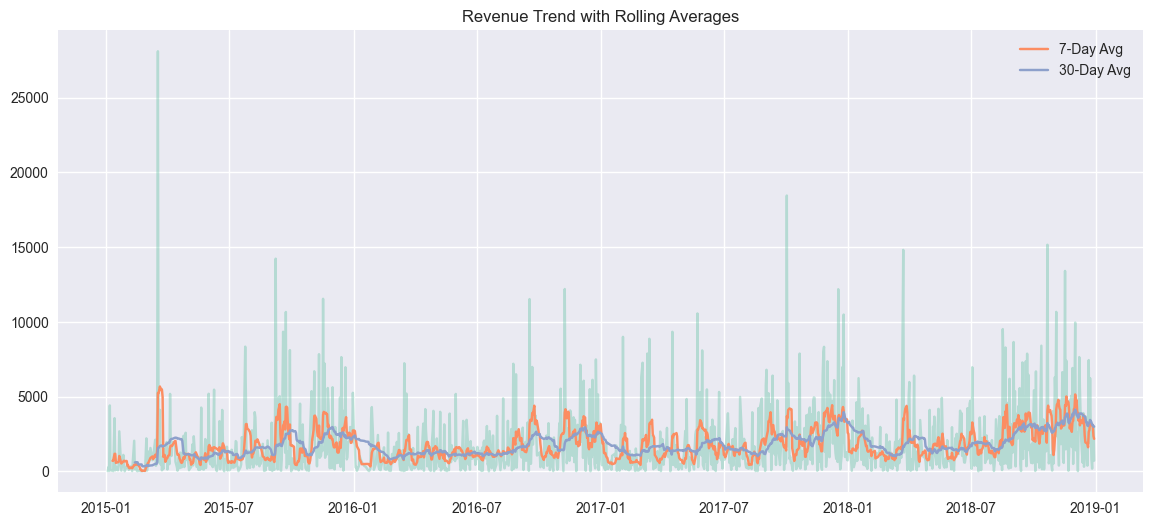

In [4]:
# 4️⃣ Aggregate Daily Revenue

daily_sales = (
    df.groupby('Order Date')['Sales']
    .sum()
    .reset_index()
)

daily_sales['Rolling_7'] = daily_sales['Sales'].rolling(7).mean()
daily_sales['Rolling_30'] = daily_sales['Sales'].rolling(30).mean()

plt.figure(figsize=(14,6))
plt.plot(daily_sales['Order Date'], daily_sales['Sales'], alpha=0.4)
plt.plot(daily_sales['Order Date'], daily_sales['Rolling_7'], label="7-Day Avg")
plt.plot(daily_sales['Order Date'], daily_sales['Rolling_30'], label="30-Day Avg")
plt.legend()
plt.title("Revenue Trend with Rolling Averages")
plt.show()

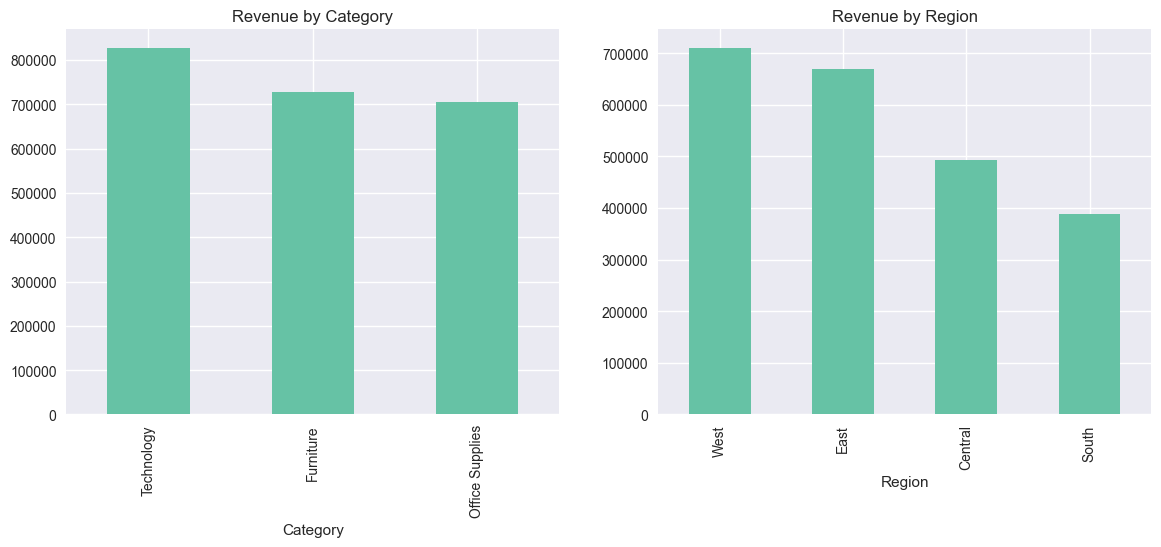

In [5]:
# 5️⃣ Category & Regional Analysis

category_totals = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
region_totals = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)

fig, axes = plt.subplots(1,2, figsize=(14,5))

category_totals.plot(kind='bar', ax=axes[0])
axes[0].set_title("Revenue by Category")

region_totals.plot(kind='bar', ax=axes[1])
axes[1].set_title("Revenue by Region")

plt.show()

# 🤖 Step 4: Time-Series Forecasting Model

We use Facebook Prophet to:

- Capture seasonality
- Model long-term trend
- Generate 90-day forecast

In [6]:
# 6️⃣ Prepare Prophet Dataset
prophet_df = daily_sales.rename(
    columns={'Order Date':'ds', 'Sales':'y'}
)

future_period = 90

train = prophet_df[:-future_period]
test = prophet_df[-future_period:]

model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False
)

model.fit(train)

future = model.make_future_dataframe(periods=future_period)
forecast = model.predict(future)

print("Model training completed.")

21:16:14 - cmdstanpy - INFO - Chain [1] start processing
21:16:14 - cmdstanpy - INFO - Chain [1] done processing


Model training completed.


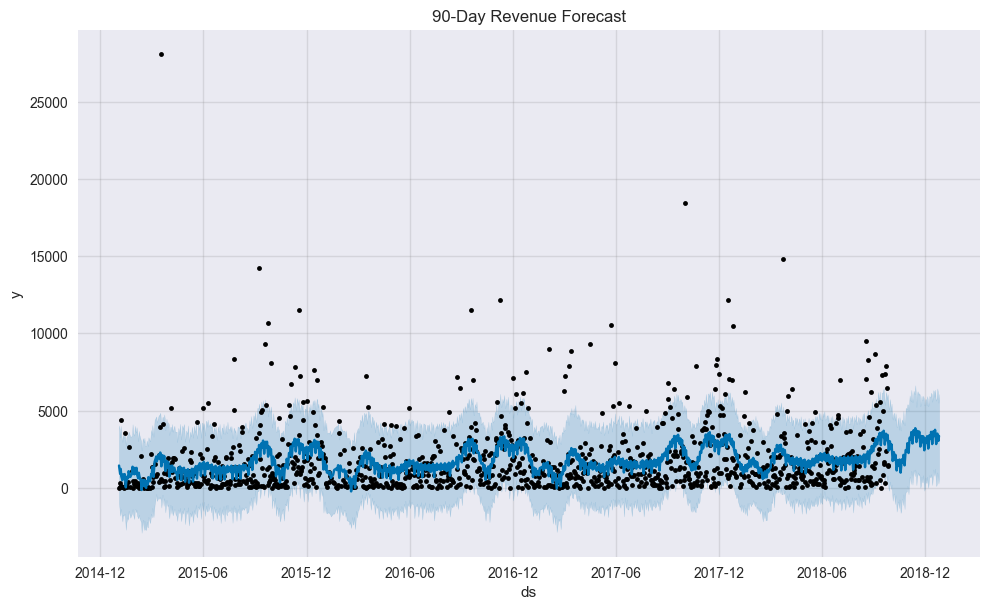

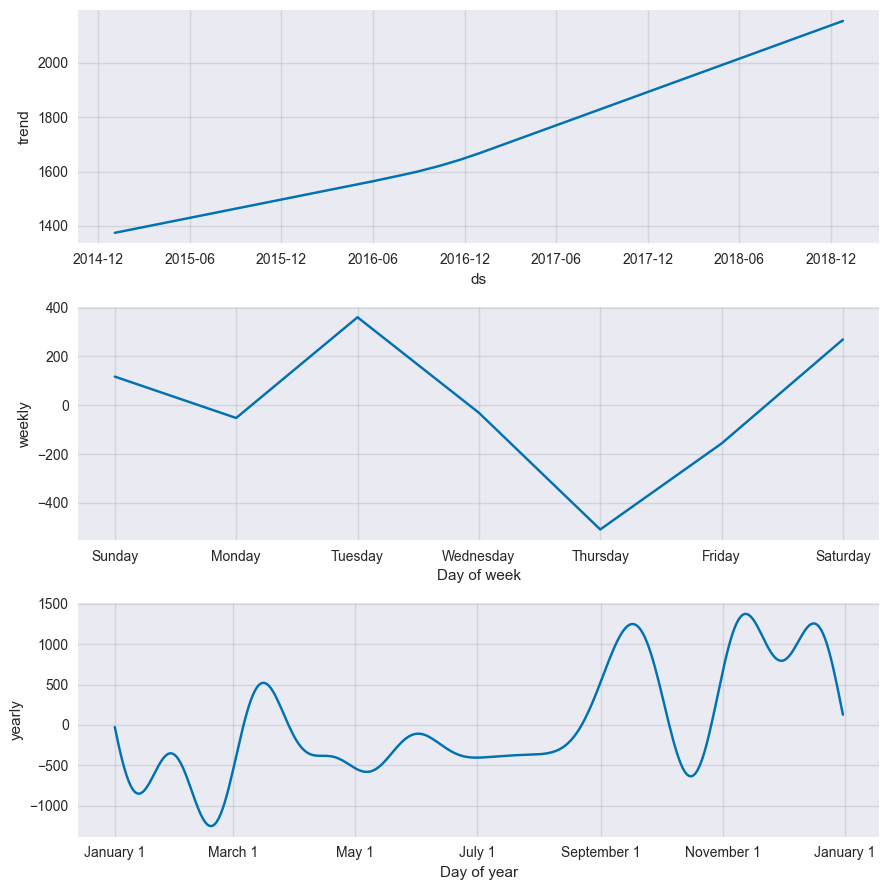

In [7]:
# 7️⃣ Forecast Visualization

fig = model.plot(forecast)
plt.title("90-Day Revenue Forecast")
plt.show()

model.plot_components(forecast)
plt.show()

# 📏 Step 5: Model Performance Evaluation

We evaluate using:

- MAE
- RMSE
- MAPE

In [8]:
# 8️⃣ Model Evaluation

predictions = forecast[-future_period:]['yhat'].values
actual = test['y'].values

mae = mean_absolute_error(actual, predictions)
rmse = np.sqrt(mean_squared_error(actual, predictions))
mape = np.mean(np.abs((actual - predictions)/actual))*100

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"MAPE : {mape:.2f}%")

MAE  : 2212.95
RMSE : 3069.42
MAPE : 756.75%


In [9]:
# 9️⃣ Linear Regression Baseline

daily_sales['Time_Index'] = np.arange(len(daily_sales))

X = daily_sales[['Time_Index']]
y = daily_sales['Sales']

lr_model = LinearRegression()
lr_model.fit(X[:-future_period], y[:-future_period])

lr_pred = lr_model.predict(X[-future_period:])

print("Baseline MAE:",
      mean_absolute_error(y[-future_period:], lr_pred))

Baseline MAE: 2151.7128624755596


# 🔮 Forecast Query System

This section simulates a real-world forecasting tool.

We can retrieve predicted sales for any future date
within the forecast horizon.

In [10]:
# 🔮 Forecast Query Function

def get_forecast_for_date(date_string):
    date = pd.to_datetime(date_string)
    result = forecast[forecast['ds'] == date]
    
    if result.empty:
        return "Date not in forecast horizon."
    
    predicted = result['yhat'].values[0]
    lower = result['yhat_lower'].values[0]
    upper = result['yhat_upper'].values[0]
    
    return {
        "Predicted Sales": round(predicted, 2),
        "Lower Bound": round(lower, 2),
        "Upper Bound": round(upper, 2)
    }

In [11]:
get_forecast_for_date("2017-12-09")

{'Predicted Sales': 3214.68, 'Lower Bound': 553.99, 'Upper Bound': 5701.21}

# 📊 Executive Business Summary

We generate dynamic KPIs and strategic insights.

In [12]:
# 🔟 Executive Summary Generator

peak_month_number = df.groupby(df['Month'])['Sales'].sum().idxmax()
peak_month = calendar.month_name[peak_month_number]

best_day = df.groupby('Day_Name')['Sales'].mean().idxmax()

last_forecast = forecast['yhat'].iloc[-1]
first_forecast = forecast['yhat'].iloc[-future_period]

projected_growth = ((last_forecast/first_forecast)-1)*100

print("\n" + "="*60)
print("📊 EXECUTIVE SALES INTELLIGENCE REPORT")
print("="*60)

print(f"\n• Historical Training Period : {len(train)} days")
print(f"• Forecast Horizon            : {future_period} days")
print(f"• Forecast Accuracy (MAPE)    : {mape:.2f}%")

print("\n📈 Revenue Insights")
print(f"• Highest Revenue Month       : {peak_month}")
print(f"• Top Performing Category     : {category_totals.idxmax()}")
print(f"• Strongest Sales Region      : {region_totals.idxmax()}")
print(f"• Highest Avg Sales Day       : {best_day}")
print(f"• Projected Growth (Quarter)  : {projected_growth:.2f}%")

print("\n" + "="*60)


📊 EXECUTIVE SALES INTELLIGENCE REPORT

• Historical Training Period : 1140 days
• Forecast Horizon            : 90 days
• Forecast Accuracy (MAPE)    : 756.75%

📈 Revenue Insights
• Highest Revenue Month       : November
• Top Performing Category     : Technology
• Strongest Sales Region      : West
• Highest Avg Sales Day       : Thursday
• Projected Growth (Quarter)  : 39.44%

